In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Major project implementation/Indoor_Plant_Health_and_Growth_Factors.csv')
df.head()

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Health_Notes,Watering_Amount_ml,Watering_Frequency_days,Sunlight_Exposure,Room_Temperature_C,Humidity_%,Fertilizer_Type,Fertilizer_Amount_ml,Pest_Presence,Pest_Severity,Soil_Moisture_%,Soil_Type,Health_Score
0,Sansevieria cylindrica,17.39,17,8,Yellowing leaves,205,3,3h direct morning sun,21.7,77.5,Organic,82,Fungus gnats,Moderate,51.9,Clay,1
1,Aloe vera,9.84,31,9,NaN,191,1,3h direct morning sun,22.6,68.9,NaN,91,Aphids,Low,28.2,Loamy,2
2,Ficus lyrata,19.82,40,8,Brittle leaves,477,5,Indirect light all day,17.2,44.3,Liquid feed,90,NaN,High,13.6,Sandy,1
3,Monstera deliciosa,37.08,11,1,New bud,207,1,Low light corner,25.0,72.2,Compost,76,Fungus gnats,Low,38.4,Sandy,4
4,Ficus lyrata,2.96,26,3,Wilting,465,2,Filtered sunlight through curtain,23.2,51.6,Compost,37,Fungus gnats,Low,37.9,Peaty,1


#Section 1:Exploratory data analysis

### Identify datatypes and check for null values in the dataset

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plant_ID                 1000 non-null   object 
 1   Height_cm                1000 non-null   float64
 2   Leaf_Count               1000 non-null   int64  
 3   New_Growth_Count         1000 non-null   int64  
 4   Health_Notes             882 non-null    object 
 5   Watering_Amount_ml       1000 non-null   int64  
 6   Watering_Frequency_days  1000 non-null   int64  
 7   Sunlight_Exposure        1000 non-null   object 
 8   Room_Temperature_C       1000 non-null   float64
 9   Humidity_%               1000 non-null   float64
 10  Fertilizer_Type          805 non-null    object 
 11  Fertilizer_Amount_ml     1000 non-null   int64  
 12  Pest_Presence            798 non-null    object 
 13  Pest_Severity            758 non-null    object 
 14  Soil_Moisture_%          

## Replace numerical columns having null values with median of the particular feature values and replace categorical columns having null values with the mode.

In [ ]:
import numpy as np
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Imputed numerical '{col}' NaNs with median.")

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Imputed categorical '{col}' NaNs with mode.")

print("\nMissing Values After Basic Imputation:")
print(f"Total missing values: {df.isnull().sum().sum()}")

Imputed categorical 'Health_Notes' NaNs with mode.
Imputed categorical 'Fertilizer_Type' NaNs with mode.
Imputed categorical 'Pest_Presence' NaNs with mode.
Imputed categorical 'Pest_Severity' NaNs with mode.

Missing Values After Basic Imputation:
Total missing values: 0


/tmp/ipykernel_186/2889414077.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


## Parse sunlight exposure by extracting the number of hours and categorizing it into types:
## Direct Sun,Morning Sun,Indirect Light,Low light, Indirect All Day Light or Others

In [ ]:
import re #Regex
def parse_sunlight_exposure_improved(exposure_str):
    if pd.isna(exposure_str):
        return 0.0, 'Unknown' # Default values for unknown
    exposure_str = str(exposure_str).lower()

    # Extract Hours
    hours_match = re.search(r'(\d+(\.\d+)?)\s*hr[s]?', exposure_str)
    duration = float(hours_match.group(1)) if hours_match else 0.0 # Default 0.0 if no hours found

    # Categorize type
    if 'direct' in exposure_str or 'full sun' in exposure_str:
        sun_type = 'Direct Sun'
    elif 'morning sun' in exposure_str:
        sun_type = 'Morning Sun'
    elif 'indirect' in exposure_str:
        sun_type = 'Indirect Light'
    elif 'filtered' in exposure_str:
        sun_type = 'Filtered Sun'
    elif 'low light' in exposure_str:
        sun_type = 'Low Light'
    elif 'all day' in exposure_str and 'indirect' in exposure_str:
        sun_type = 'Indirect All Day'
    else:
        sun_type = 'Other/Unspecified'

    return duration, sun_type

df['Sunlight_Duration_hrs_EDA'], df['Sunlight_Type_EDA'] = zip(*df['Sunlight_Exposure'].apply(parse_sunlight_exposure_improved))

## Creating and cleaning a new feature called Watering_Per_Day_ml_EDA to estimate how much water a plant gets per day on average

In [ ]:
df['Watering_Per_Day_ml_EDA'] = df['Watering_Amount_ml'] / df['Watering_Frequency_days']
# Handle division by zero or inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df['Watering_Per_Day_ml_EDA'].fillna(df['Watering_Per_Day_ml_EDA'].median(), inplace=True) # Fill NaNs (e.g., from 0 freq)

/tmp/ipykernel_186/1824632210.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Watering_Per_Day_ml_EDA'].fillna(df['Watering_Per_Day_ml_EDA'].median(), inplace=True) # Fill NaNs (e.g., from 0 freq)


## Simple parsing of Health_Notes for keywords
## Feature Extraction from text in the Health_Notes column to convert text descriptions of plant health into numerical features (0 or 1) for a machine learning model

## Yellowing → nutrient deficiency

## Wilting → water stress

## Browning → disease/pests

## New bud → healthy growth

In [ ]:
df['Has_Yellowing'] = df['Health_Notes'].str.contains('yellow', case=False, na=False).astype(int)
df['Has_Wilting'] = df['Health_Notes'].str.contains('wilting', case=False, na=False).astype(int)
df['Has_Browning'] = df['Health_Notes'].str.contains('browning', case=False, na=False).astype(int)
df['Has_Strong_Stem'] = df['Health_Notes'].str.contains('strong stem', case=False, na=False).astype(int)
df['Has_New_Bud'] = df['Health_Notes'].str.contains('new bud', case=False, na=False).astype(int)

# Section 2 : Data Visualization

## Distribution of Plant Health Score

/tmp/ipykernel_186/979070123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Health_Score', data=df, palette='viridis')


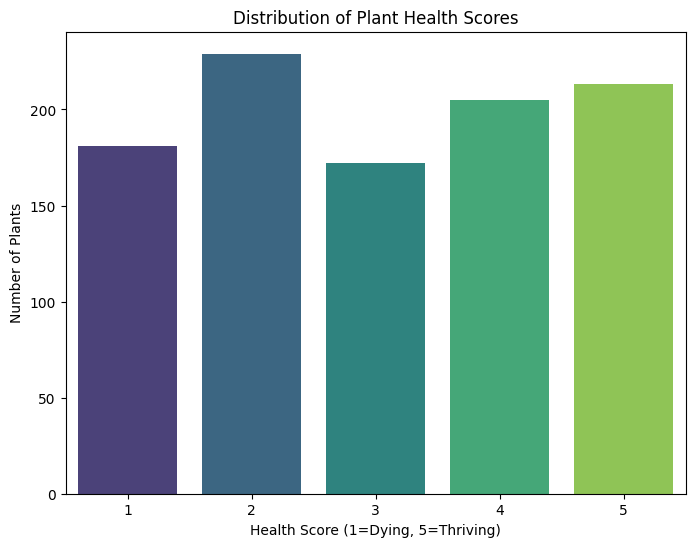

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.countplot(x='Health_Score', data=df, palette='viridis')
plt.title('Distribution of Plant Health Scores')
plt.xlabel('Health Score (1=Dying, 5=Thriving)')
plt.ylabel('Number of Plants')
plt.show()

##Correlation Heatmap Interpretation:

## Watering_Frequency_days vs Watering_Per_Day_ml_EDA: Strong negative correlation of -0.70, indicating that as watering frequency increases, average daily watering decreases.

## Watering_Amount_ml vs Watering_Per_Day_ml_EDA: Moderate positive correlation 0.50, meaning higher watering amounts lead to higher daily water supply.

##Growth indicators (Height, Leaf_Count, New_Growth_Count): Show very weak correlations with each other and with Health_Score.

##Environmental features (Temperature, Humidity): Very weak correlations, indicating minimal direct relationships.

##Health note indicators (Yellowing, Wilting, New Bud, Strong Stem): Weak correlations, suggesting symptoms occur independently in most cases.

##Indicating low multicollinearity among features.

##Independent features make the dataset suitable for tree-based models like XGBoost, which can capture nonlinear relationships.

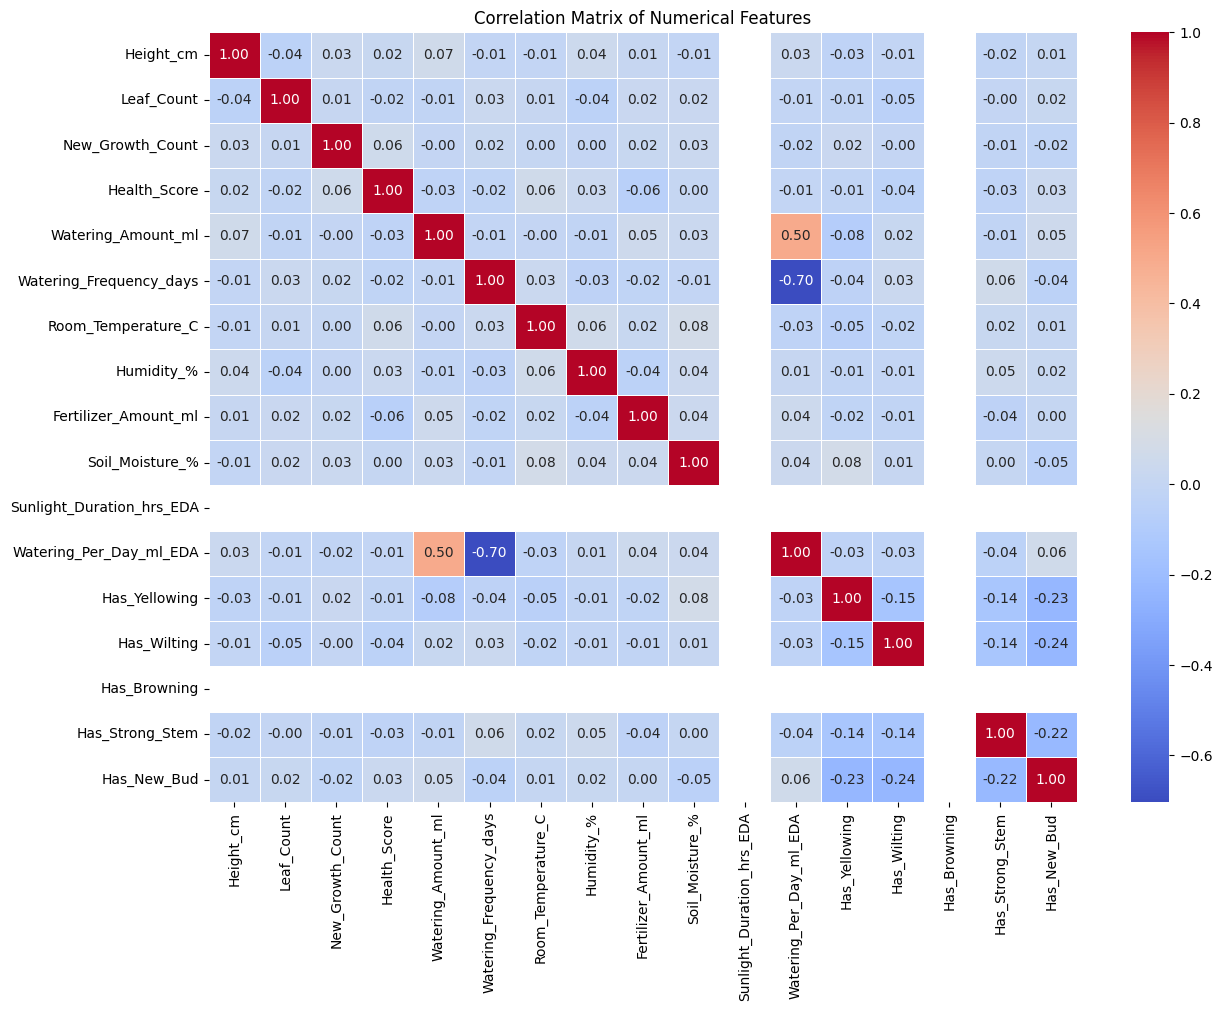

In [ ]:
numerical_cols_for_corr = [
    'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Score',
    'Watering_Amount_ml', 'Watering_Frequency_days', 'Room_Temperature_C',
    'Humidity_%', 'Fertilizer_Amount_ml', 'Soil_Moisture_%',
    'Sunlight_Duration_hrs_EDA', 'Watering_Per_Day_ml_EDA',
    'Has_Yellowing', 'Has_Wilting', 'Has_Browning', 'Has_Strong_Stem', 'Has_New_Bud' # Include new features
]
corr_matrix = df[numerical_cols_for_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Health Score for Top 20 most common plant species


/tmp/ipykernel_186/1963400496.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_ID', y='Health_Score', data=df[df['Plant_ID'].isin(top_n_plants)], palette='pastel')


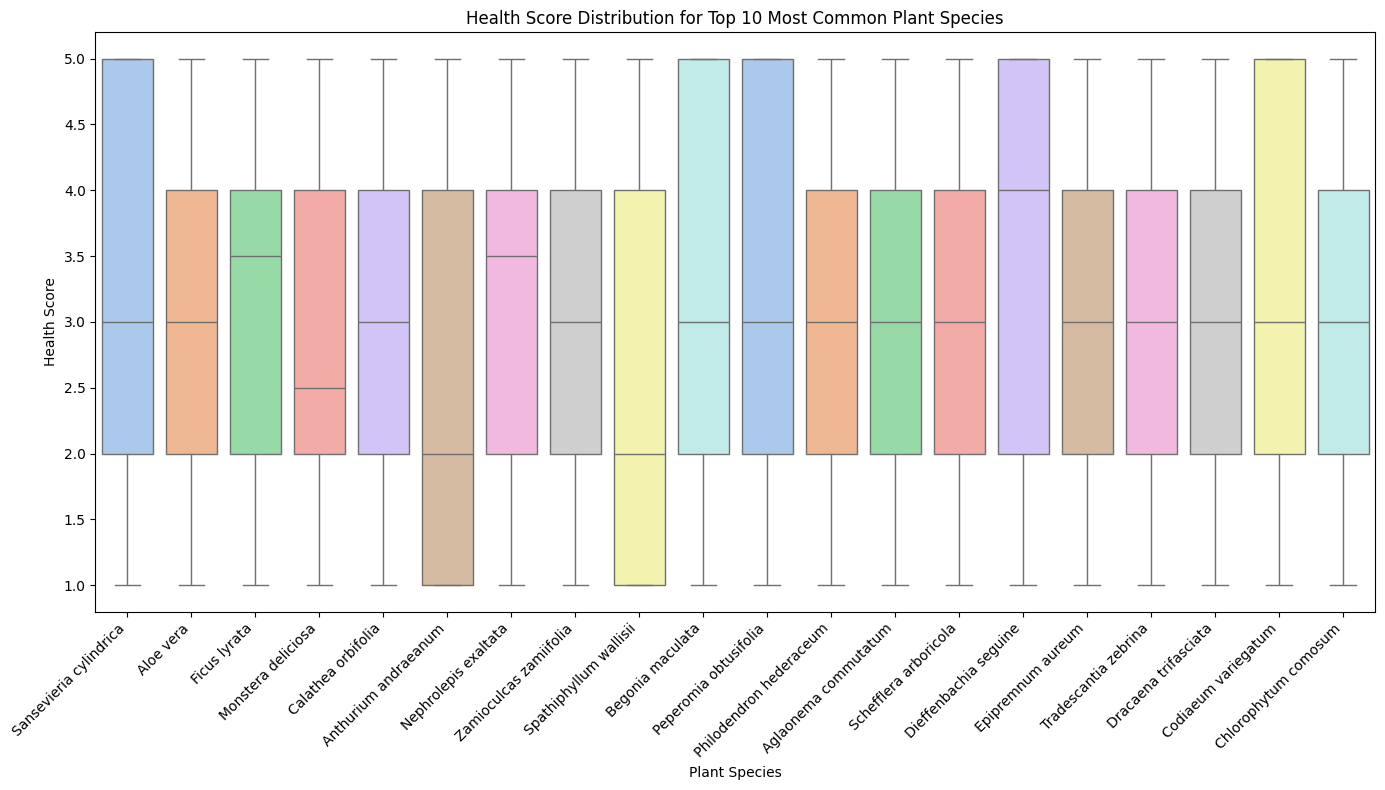

In [ ]:

top_n_plants = df['Plant_ID'].value_counts().nlargest(20).index

plt.figure(figsize=(14, 8))
sns.boxplot(x='Plant_ID', y='Health_Score', data=df[df['Plant_ID'].isin(top_n_plants)], palette='pastel')
plt.title('Health Score Distribution for Top 10 Most Common Plant Species')
plt.xlabel('Plant Species')
plt.ylabel('Health Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Influence of Sunlight_Type_EDA on New Growth and Health Score

/tmp/ipykernel_186/750561702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sunlight_Type_EDA', y='New_Growth_Count', data=df, palette='magma',


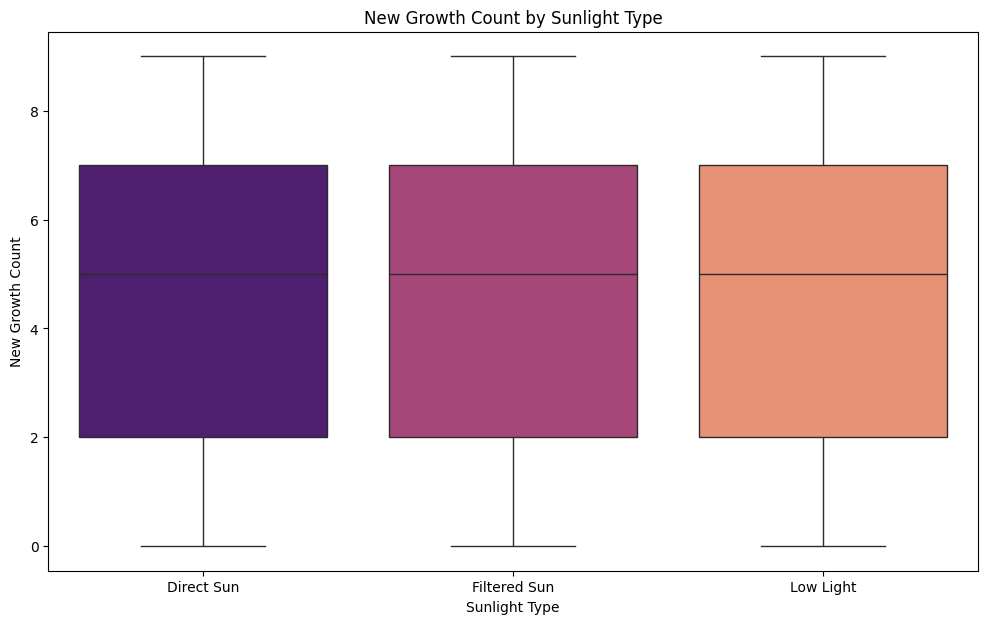

/tmp/ipykernel_186/750561702.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sunlight_Type_EDA', y='Health_Score', data=df, palette='RdYlGn',


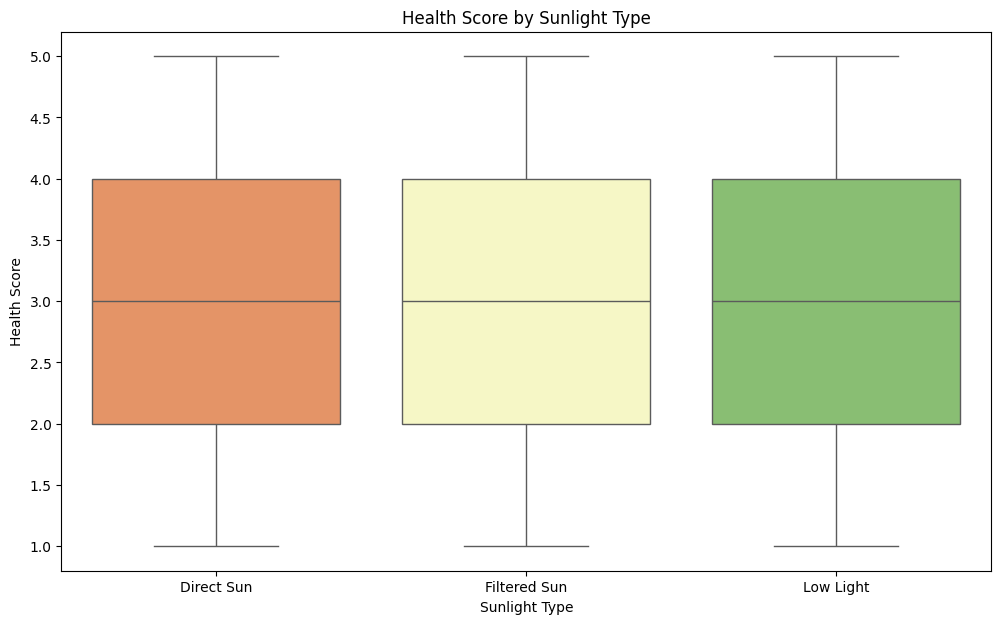

In [ ]:

plt.figure(figsize=(12, 7))
sns.boxplot(x='Sunlight_Type_EDA', y='New_Growth_Count', data=df, palette='magma',
            order=df['Sunlight_Type_EDA'].value_counts().index) # Order by frequency
plt.title('New Growth Count by Sunlight Type')
plt.xlabel('Sunlight Type')
plt.ylabel('New Growth Count')
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x='Sunlight_Type_EDA', y='Health_Score', data=df, palette='RdYlGn',
            order=df['Sunlight_Type_EDA'].value_counts().index) # Order by frequency
plt.title('Health Score by Sunlight Type')
plt.xlabel('Sunlight Type')
plt.ylabel('Health Score')
plt.show()

## Watering Trends vs. Soil Moisture levels

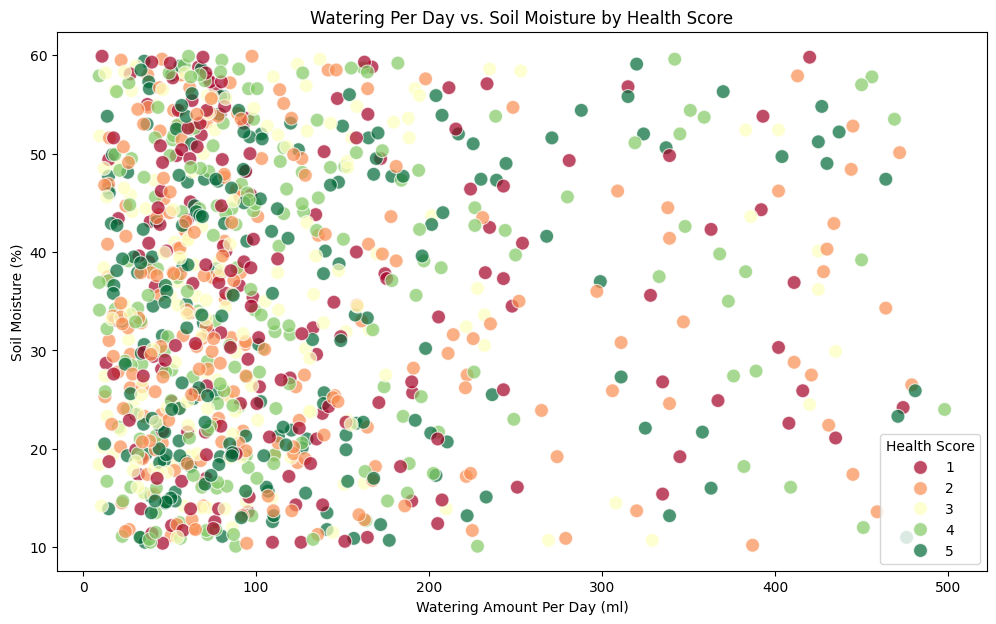

In [ ]:

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Watering_Per_Day_ml_EDA', y='Soil_Moisture_%', hue='Health_Score', data=df, palette='RdYlGn', s=100, alpha=0.7)
plt.title('Watering Per Day vs. Soil Moisture by Health Score')
plt.xlabel('Watering Amount Per Day (ml)')
plt.ylabel('Soil Moisture (%)')
plt.legend(title='Health Score')
plt.show()

##How Health_Notes Keywords relate to Health_Score

/tmp/ipykernel_186/1686301550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Yellowing', y='Health_Score', data=df, palette='coolwarm', ax=axes[0])
/tmp/ipykernel_186/1686301550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Wilting', y='Health_Score', data=df, palette='coolwarm', ax=axes[1])
/tmp/ipykernel_186/1686301550.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Has_Browning', y='Health_Score', data=df, palette='coolwarm', ax=axes[2])
/tmp/ipykernel_186/1686301550.py:17: FutureWarning: 

Passing `palett

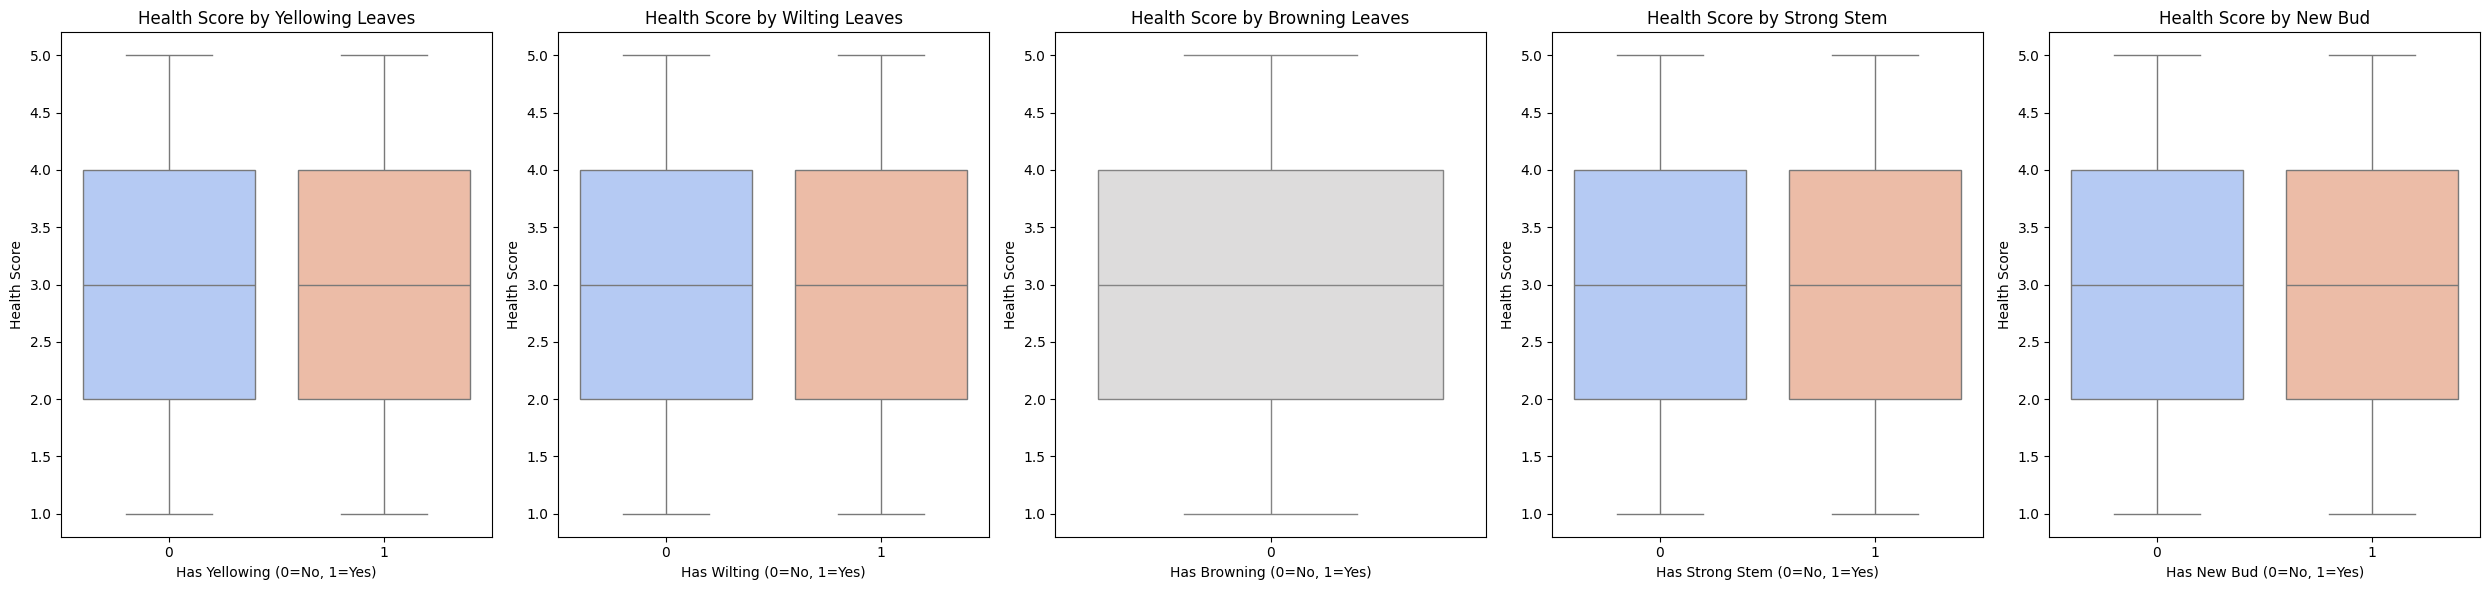

In [ ]:

fig, axes = plt.subplots(1, 5, figsize=(25, 6)) # Updated for more features
sns.boxplot(x='Has_Yellowing', y='Health_Score', data=df, palette='coolwarm', ax=axes[0])
axes[0].set_title('Health Score by Yellowing Leaves')
axes[0].set_xlabel('Has Yellowing (0=No, 1=Yes)')
axes[0].set_ylabel('Health Score')

sns.boxplot(x='Has_Wilting', y='Health_Score', data=df, palette='coolwarm', ax=axes[1])
axes[1].set_title('Health Score by Wilting Leaves')
axes[1].set_xlabel('Has Wilting (0=No, 1=Yes)')
axes[1].set_ylabel('Health Score')

sns.boxplot(x='Has_Browning', y='Health_Score', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title('Health Score by Browning Leaves')
axes[2].set_xlabel('Has Browning (0=No, 1=Yes)')
axes[2].set_ylabel('Health Score')

sns.boxplot(x='Has_Strong_Stem', y='Health_Score', data=df, palette='coolwarm', ax=axes[3])
axes[3].set_title('Health Score by Strong Stem')
axes[3].set_xlabel('Has Strong Stem (0=No, 1=Yes)')
axes[3].set_ylabel('Health Score')

sns.boxplot(x='Has_New_Bud', y='Health_Score', data=df, palette='coolwarm', ax=axes[4])
axes[4].set_title('Health Score by New Bud')
axes[4].set_xlabel('Has New Bud (0=No, 1=Yes)')
axes[4].set_ylabel('Health Score')

plt.tight_layout()
plt.show()

## Weak Correlation among features against the target variable Health_Score

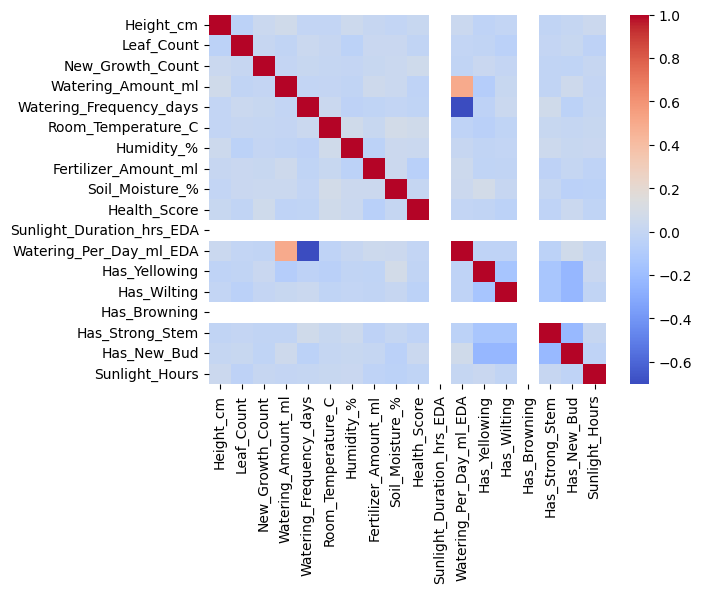

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

## Section 3: Clustering to identify and uncover hidden patterns

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

## I created a new dataframe to avoid modifying the original dataset and keep clustering as a completely seperate entity in the pipeline

In [ ]:

df_cluster = pd.read_csv('/content/drive/MyDrive/Major project implementation/Indoor_Plant_Health_and_Growth_Factors.csv')

## For all the missing numerical data in columns, replace with median
## For all the missing categorical data in columns, replace with mode

In [ ]:
# Impute missing values (numerical with median, categorical with mode)
for col in df_cluster.select_dtypes(include=np.number).columns:
    if df_cluster[col].isnull().any():
        df_cluster[col].fillna(df_cluster[col].median(), inplace=True)
        print(f"Imputed numerical '{col}' NaNs with median.")

for col in df_cluster.select_dtypes(include='object').columns:
    if df_cluster[col].isnull().any():
        df_cluster[col].fillna(df_cluster[col].mode()[0], inplace=True)
        print(f"Imputed categorical '{col}' NaNs with mode.")

# Watering_Per_Day_ml
df_cluster['Watering_Per_Day_ml_Cluster'] = df_cluster['Watering_Amount_ml'] / df_cluster['Watering_Frequency_days']
df_cluster.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cluster['Watering_Per_Day_ml_Cluster'].fillna(df_cluster['Watering_Per_Day_ml_Cluster'].median(), inplace=True)

Imputed categorical 'Health_Notes' NaNs with mode.
Imputed categorical 'Fertilizer_Type' NaNs with mode.
Imputed categorical 'Pest_Presence' NaNs with mode.
Imputed categorical 'Pest_Severity' NaNs with mode.


/tmp/ipykernel_186/184382203.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cluster[col].fillna(df_cluster[col].mode()[0], inplace=True)
/tmp/ipykernel_186/184382203.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [ ]:
features_for_clustering = [
    'Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%',
    'Watering_Per_Day_ml_Cluster',
    'Fertilizer_Type', 'Soil_Type',
    'Watering_Frequency_days',
    'Fertilizer_Amount_ml',
    #'Pest_Severity', # Pest severity is neglected as it is not a part of our problem statement right now
    'Plant_ID' # Include Plant_ID for clustering specific needs
]

X_cluster = df_cluster[features_for_clustering].copy()

# Numerical and categorical features for the preprocessor
numerical_features_cluster = X_cluster.select_dtypes(include=np.number).columns.tolist()
categorical_features_cluster = X_cluster.select_dtypes(include='object').columns.tolist()


In [ ]:
# Preprocessing Pipeline for Clustering
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_cluster),## numerical values
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_cluster),#categorical values
    ])

print("\nData preprocessing setup for clustering complete.")


#Determine Optimal Number of Clusters (Elbow Method)
X_scaled_clustered = preprocessor_cluster.fit_transform(X_cluster)

# Check for NaNs or Infs in the transformed data after converting to a dense array
X_scaled_dense = X_scaled_clustered.toarray()



Data preprocessing setup for clustering complete.


## The elbow point in K-Means Clustering is the value of K where increasing the number of clusters stops significantly reducing inertia, forming a bend (“elbow”) in the inertia vs. K plot.

In [ ]:
if np.isnan(X_scaled_dense).any() or np.isinf(X_scaled_dense).any():
    print("WARNING: NaNs or Infs found in scaled data. This can cause issues with KMeans.")
    #Add imputation if NaNs found
    # Apply nan_to_num to the dense array
    X_scaled_dense = np.nan_to_num(X_scaled_dense, nan=0.0, posinf=1e5, neginf=-1e5)
    print("NaNs/Infs replaced with 0 or large values for robustness.")
else:
    pass # No action needed if no NaNs/Infs


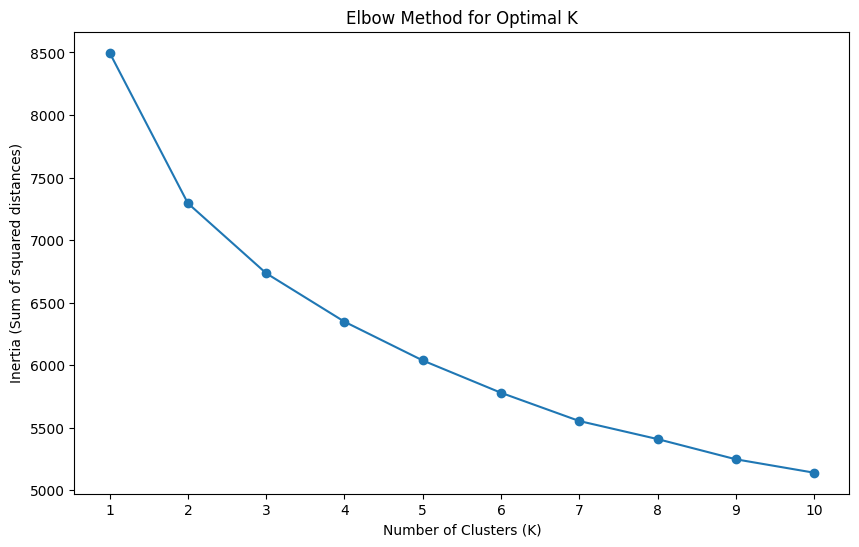

In [ ]:
inertias = []
max_k = 10 # Max 10 clusters
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for robust centroid initialization
    kmeans.fit(X_scaled_dense) # Use X_scaled_dense here
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.xticks(range(1, max_k + 1))
plt.show()

In [ ]:
print("Look for the 'elbow point' in the plot to decide optimal K.")
# Looking at graph, K=3, 4, or 5 might be a reasonable starting point.
optimal_k = 4

# Apply K-Means Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# Fit and predict
df_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled_dense)

print(f"\nClustering performed with K = {optimal_k}.")
print(f"Cluster distribution:\n{df_cluster['Cluster'].value_counts()}")


Look for the 'elbow point' in the plot to decide optimal K.

Clustering performed with K = 4.
Cluster distribution:
Cluster
0    272
3    256
1    250
2    222
Name: count, dtype: int64


In [ ]:
# Analyze Cluster Characteristics
# Get feature names after all transformations for better interpretability of cluster centroids
numerical_feature_names = numerical_features_cluster
categorical_ohe_feature_names = preprocessor_cluster.named_transformers_['cat'].get_feature_names_out(categorical_features_cluster) # Corrected access


all_transformed_feature_names = list(numerical_feature_names) + list(categorical_ohe_feature_names)

# Convert scaled centroids back to original scale where possible for numerical features
# Note: This requires reversing the StandardScaler, which is complex for all features simultaneously
# A simpler way is to analyze the means of the *original* features grouped by cluster
cluster_means_original_scale = df_cluster.groupby('Cluster')[numerical_features_cluster].mean()
print("\n Cluster Mean Values (Numerical Features - Original Scale) ")
print(cluster_means_original_scale)
# Also check categorical feature distributions within clusters
for cat_col in categorical_features_cluster: # Loop through original categorical and ordinal
    print(f"\n Distribution of {cat_col} within Clusters")
    print(pd.crosstab(df_cluster['Cluster'], df_cluster[cat_col], normalize='index'))


--- Cluster Mean Values (Numerical Features - Original Scale) ---
         Room_Temperature_C  Humidity_%  Soil_Moisture_%  \
Cluster                                                    
0                 22.000735   48.806985        21.772426   
1                 25.281600   59.384000        41.166800   
2                 23.684685   54.943694        35.735586   
3                 24.941406   56.204297        41.334375   

         Watering_Per_Day_ml_Cluster  Watering_Frequency_days  \
Cluster                                                         
0                          76.202635                 3.871324   
1                          72.245400                 4.080000   
2                         276.881381                 1.274775   
3                          74.013607                 4.171875   

         Fertilizer_Amount_ml  
Cluster                        
0                   43.966912  
1                   21.940000  
2                   50.063063  
3                   7

## Cluster 0 – Low Moisture / Moderate Care Plants
- **Temperature:** ~22°C (coolest cluster)
- **Humidity:** ~48.8% (lowest)
- **Soil Moisture:** ~21.8% (very dry soil)
- **Watering:** ~76 ml every ~3.9 days
- **Fertilizer Amount:** ~44 ml

**Interpretation:**  
Plants in this cluster tolerate **dry soil and lower humidity**. They require **less frequent watering** and moderate fertilizer.

---

## Cluster 1 – Warm & Moderate Moisture Plants
- **Temperature:** ~25.3°C (warmest cluster)
- **Humidity:** ~59%
- **Soil Moisture:** ~41%
- **Watering:** ~72 ml every ~4 days
- **Fertilizer Amount:** ~22 ml (lowest fertilizer)

**Interpretation:**  
Plants in this cluster prefer **warmer environments with moderate moisture**. They require **stable watering but minimal fertilizer input**.

---

## Cluster 2 – High Water Demand Plants
- **Temperature:** ~23.7°C
- **Humidity:** ~54.9%
- **Soil Moisture:** ~35.7%
- **Watering:** ~277 ml every ~1.27 days (highest watering)
- **Fertilizer Amount:** ~50 ml

**Interpretation:**  
Plants in this cluster require **frequent watering and consistent moisture**. These are likely **fast-growing or tropical plants with high water demand**.

---

## Cluster 3 – High Nutrient Requirement Plants
- **Temperature:** ~24.9°C
- **Humidity:** ~56.2%
- **Soil Moisture:** ~41.3%
- **Watering:** ~74 ml every ~4.2 days
- **Fertilizer Amount:** ~77 ml (highest fertilizer)

**Interpretation:**  
Plants in this cluster require **higher fertilizer input** while maintaining **moderate watering and humidity levels**.

## Cluster Visualization

### 1. Heatmap of Cluster Mean Feature Values

The heatmap visualizes the **average feature values for each cluster**, allowing us to easily compare plant care conditions such as temperature, humidity, soil moisture, watering, and fertilizer requirements.


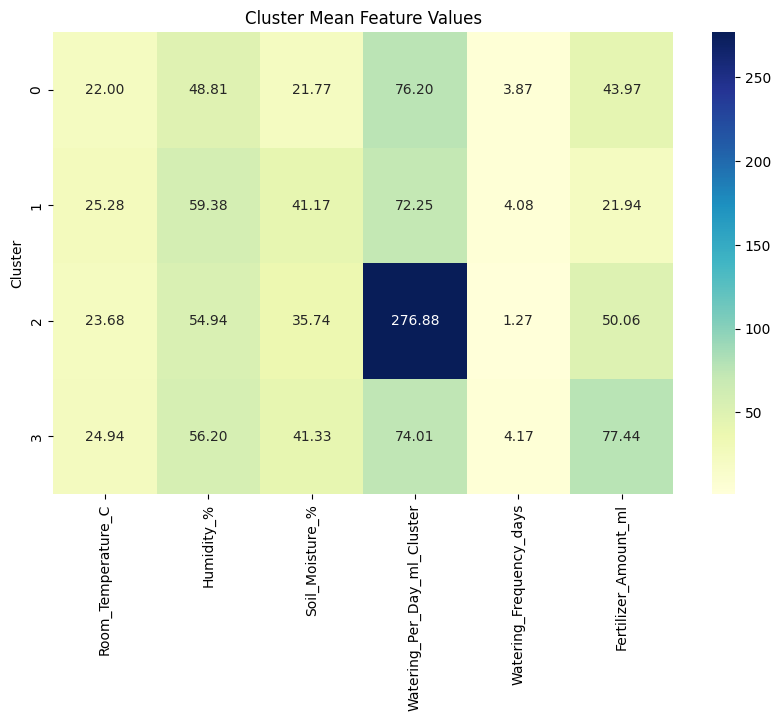

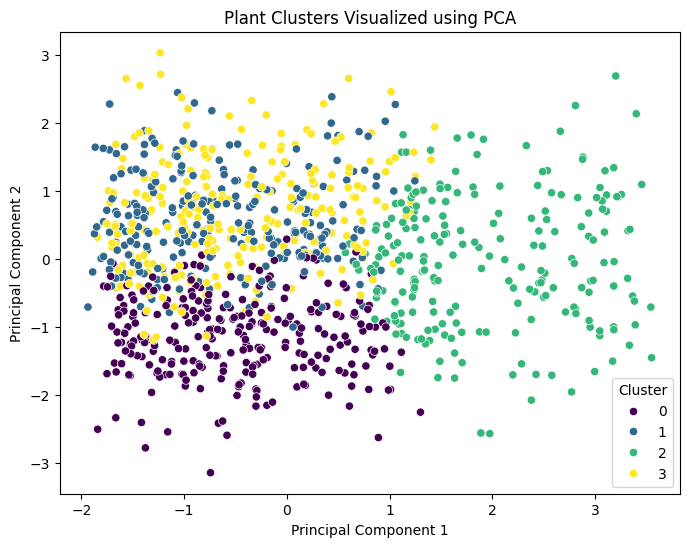

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cluster_means = df_cluster.groupby('Cluster')[[
    'Room_Temperature_C',
    'Humidity_%',
    'Soil_Moisture_%',
    'Watering_Per_Day_ml_Cluster',
    'Watering_Frequency_days',
    'Fertilizer_Amount_ml'
]].mean()

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cluster Mean Feature Values")
plt.show()


#PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_dense)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df_cluster['Cluster'],
    palette='viridis'
)

plt.title("Plant Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
df_model = df_cluster.copy()

X = df_model.drop(columns=['Health_Score','Health_Notes'])
y = df_model['Health_Score']

## Checked health_score across clusters

In [ ]:
pd.crosstab(df_cluster['Cluster'], df_cluster['Health_Score'], normalize='index')

Health_Score,1,2,3,4,5
Cluster,,,,,
0,0.205882,0.235294,0.158088,0.191176,0.209559
1,0.136000,0.188000,0.176000,0.264000,0.236000
2,0.207207,0.238739,0.144144,0.198198,0.211712
3,0.175781,0.253906,0.207031,0.167969,0.195312


In [ ]:


importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print(importance.head(15))

Fertilizer_Amount_ml           0.197402
Watering_Per_Day_ml_Cluster    0.161345
Soil_Moisture_%                0.128523
Watering_Frequency_days        0.107233
Room_Temperature_C             0.078284
Humidity_%                     0.049165
Watering_Amount_ml             0.041122
Height_cm                      0.032301
Leaf_Count                     0.027586
New_Growth_Count               0.019647
Pest_Presence_Whiteflies       0.005852
Fertilizer_Type_Chemical       0.005619
Pest_Severity_Low              0.005514
Fertilizer_Type_Organic        0.005089
Soil_Type_Chalky               0.005072
dtype: float64


In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)

selected_features = importance[importance > 0.03].index

print(selected_features)

Index(['Height_cm', 'Watering_Amount_ml', 'Watering_Frequency_days',
       'Room_Temperature_C', 'Humidity_%', 'Fertilizer_Amount_ml',
       'Soil_Moisture_%', 'Watering_Per_Day_ml_Cluster'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)

selector = RFE(rf, n_features_to_select=8)

selector.fit(X, y)

selected = X.columns[selector.support_]

print("Selected features:", selected)

Selected features: Index(['Height_cm', 'Watering_Amount_ml', 'Watering_Frequency_days',
       'Room_Temperature_C', 'Humidity_%', 'Fertilizer_Amount_ml',
       'Soil_Moisture_%', 'Watering_Per_Day_ml_Cluster'],
      dtype='object')


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_scores.head(10))

Watering_Per_Day_ml_Cluster    0.420517
Fertilizer_Amount_ml           0.362163
Watering_Frequency_days        0.340511
Soil_Moisture_%                0.175916
Room_Temperature_C             0.090846
Watering_Amount_ml             0.051219
Pest_Presence_Aphids           0.038805
Fertilizer_Type_Organic        0.036544
Soil_Type_Loamy                0.034854
Humidity_%                     0.034199
dtype: float64


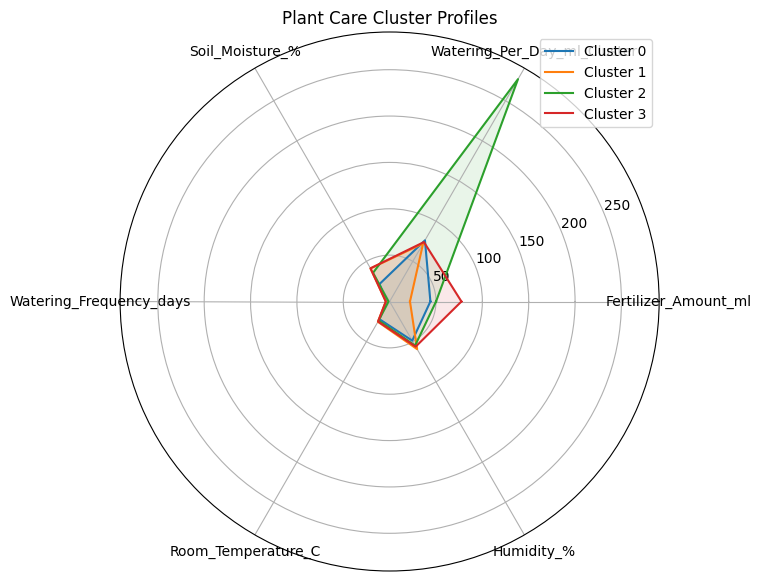

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

features = [
    'Fertilizer_Amount_ml',
    'Watering_Per_Day_ml_Cluster',
    'Soil_Moisture_%',
    'Watering_Frequency_days',
    'Room_Temperature_C',
    'Humidity_%'
]

cluster_means = df_cluster.groupby('Cluster')[features].mean()

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

for cluster in cluster_means.index:

    values = cluster_means.loc[cluster].tolist()
    values += values[:1]

    ax.plot(angles, values, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Plant Care Cluster Profiles")
plt.legend()
plt.show()

Cluster prediction accuracy: 0.85


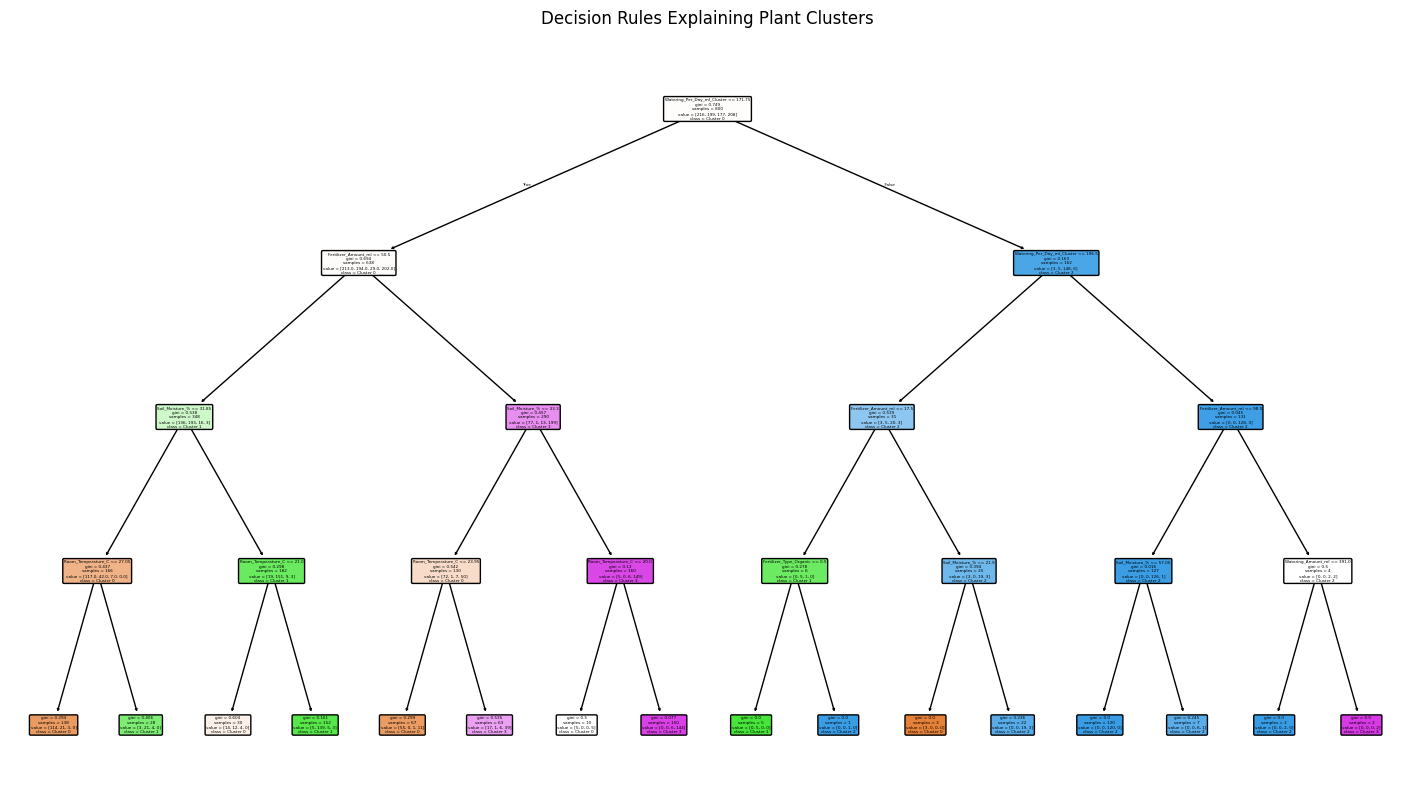

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_cluster.drop(columns=['Cluster','Health_Score','Health_Notes'])
y = df_cluster['Cluster']

# encode categorical features
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

tree = DecisionTreeClassifier(
    max_depth=4,  # keeps tree interpretable
    random_state=42
)

tree.fit(X_train, y_train)

print("Cluster prediction accuracy:", tree.score(X_test, y_test))
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['Cluster 0','Cluster 1','Cluster 2','Cluster 3'],
    filled=True,
    rounded=True
)

plt.title("Decision Rules Explaining Plant Clusters")
plt.show()

<Axes: >

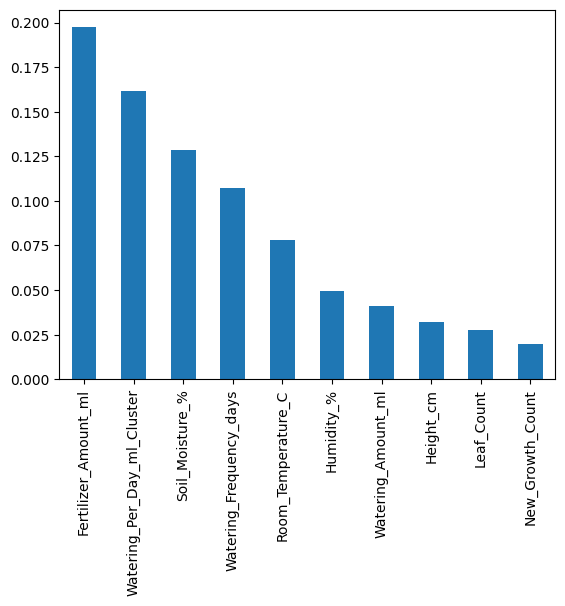

In [ ]:
importance.head(10).plot.bar()

In [ ]:
cluster_profile = df_cluster.groupby("Cluster")[[
    'Room_Temperature_C',
    'Humidity_%',
    'Soil_Moisture_%',
    'Watering_Per_Day_ml_Cluster',
    'Watering_Frequency_days',
    'Fertilizer_Amount_ml'
]].mean()

print(cluster_profile)

         Room_Temperature_C  Humidity_%  Soil_Moisture_%  \
Cluster                                                    
0                 22.000735   48.806985        21.772426   
1                 25.281600   59.384000        41.166800   
2                 23.684685   54.943694        35.735586   
3                 24.941406   56.204297        41.334375   

         Watering_Per_Day_ml_Cluster  Watering_Frequency_days  \
Cluster                                                         
0                          76.202635                 3.871324   
1                          72.245400                 4.080000   
2                         276.881381                 1.274775   
3                          74.013607                 4.171875   

         Fertilizer_Amount_ml  
Cluster                        
0                   43.966912  
1                   21.940000  
2                   50.063063  
3                   77.441406  
